In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#  Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import string
import re
import datetime

from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve , auc, RocCurveDisplay

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Loading and viewing data

In [4]:
data=pd.read_csv("/content/drive/MyDrive/ml_data/recipe_ratings_train.csv")

In [5]:
data.shape  # no.of rows and columns present

(13636, 15)

In [6]:
data.columns

Index(['ID', 'RecipeNumber', 'RecipeCode', 'RecipeName', 'CommentID', 'UserID',
       'UserName', 'UserReputation', 'CreationTimestamp', 'ReplyCount',
       'ThumbsUpCount', 'ThumbsDownCount', 'Rating', 'BestScore',
       'Recipe_Review'],
      dtype='object')

In [7]:
data.head()

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
0,70,71,12259,Banana Bars with Cream Cheese Frosting,sp_aUSaElGf_12259_c_149978,u_1oKVaBmiEKwAFyiHrDLoWpbel0J,misscoffeepot,20,1622717078,0,0,0,5,100,great recipe! I have made them just as written...
1,72,88,8202,Simple Taco Soup,sp_aUSaElGf_8202_c_310332,u_1oKZeRIXYzGNhGW8OMR3O4lX1ih,MichelleMalone,1,1622717852,0,0,1,5,100,This is an easy and quick recipe that is great...
2,458,3,2832,Cheeseburger Soup,sp_aUSaElGf_2832_c_206522,u_1oKYHUtdaD48KJCDYq5wfpAUxWz,jeannem32,1,1622717357,0,0,0,3,100,I think I was looking for something extra spec...
3,7,50,100276,Grilled Huli Huli Chicken,sp_aUSaElGf_100276_c_434088,u_1oKZCQcKQZdQhDVBS7oISc216VA,ds422,1,1622648899,0,0,0,5,100,This is our favorite grilled chicken recipe. ...
4,60,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_387011,u_1oKd4sudZQPgu6YALiC7bW7mKMs,SusanHoward,1,1622718260,0,0,0,4,100,Great basic recipe. I added 2 teaspoons Tuscan...


In [8]:
data.info()   #checking for datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13636 entries, 0 to 13635
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 13636 non-null  int64 
 1   RecipeNumber       13636 non-null  int64 
 2   RecipeCode         13636 non-null  int64 
 3   RecipeName         13636 non-null  object
 4   CommentID          13636 non-null  object
 5   UserID             13636 non-null  object
 6   UserName           13636 non-null  object
 7   UserReputation     13636 non-null  int64 
 8   CreationTimestamp  13636 non-null  int64 
 9   ReplyCount         13636 non-null  int64 
 10  ThumbsUpCount      13636 non-null  int64 
 11  ThumbsDownCount    13636 non-null  int64 
 12  Rating             13636 non-null  int64 
 13  BestScore          13636 non-null  int64 
 14  Recipe_Review      13634 non-null  object
dtypes: int64(10), object(5)
memory usage: 1.6+ MB


In [9]:
#converting unix CreationTimestamp to time date format
data['CreationTimestamp'] = pd.to_datetime(
    data['CreationTimestamp'],
    unit='s'
)

In [10]:
data.isnull().sum()  #checking for null values

,0
ID,0
RecipeNumber,0
RecipeCode,0
RecipeName,0
CommentID,0
UserID,0
UserName,0
UserReputation,0
CreationTimestamp,0
ReplyCount,0


In [11]:
Percentage=data['Recipe_Review'].isnull().sum()/data.shape[0]
Percentage

np.float64(0.00014667057788207686)

the missing values might not be very informative due to the small proportion of missing data so we can drop those values

In [12]:
data.dropna(inplace=True) #dropping null values

In [13]:
data.describe(include='all') #Statistical summary

,ID,RecipeNumber,RecipeCode,RecipeName,CommentID,UserID,UserName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,BestScore,Recipe_Review
count,13634.00000,13634.000000,13634.000000,13634,13634,13634,13634,13634.000000,13634,13634.000000,13634.000000,13634.000000,13634.000000,13634.00000,13634
unique,NaN,NaN,NaN,100,13634,10782,10619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13370
top,NaN,NaN,NaN,Cheeseburger Soup,sp_aUSaElGf_2832_c_278956,u_1oKVZoIOMWJ2j7TA7py2BIbf1mm,mjlouk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Delicious!
freq,NaN,NaN,NaN,552,1,20,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
mean,121.05589,38.629382,21787.406117,NaN,NaN,NaN,NaN,2.160481,2021-06-14 23:32:35.414845184,0.014523,1.098430,0.543788,4.288617,153.13569,NaN
min,0.00000,1.000000,386.000000,NaN,NaN,NaN,NaN,0.000000,2021-02-11 09:22:16,0.000000,0.000000,0.000000,0.000000,0.00000,NaN
25%,45.00000,12.000000,6504.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 10:47:22,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
50%,91.00000,33.000000,14600.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 10:55:07,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
75%,148.00000,63.000000,33121.000000,NaN,NaN,NaN,NaN,1.000000,2021-06-03 11:02:52,0.000000,0.000000,0.000000,5.000000,100.00000,NaN
max,724.00000,100.000000,191775.000000,NaN,NaN,NaN,NaN,510.000000,2022-10-14 14:00:35,3.000000,80.000000,126.000000,5.000000,946.00000,NaN


* most frequent value in the RecipeName column is "Cheeseburger Soup", which appears 552 times.
* the minimum rating is 0 and maximum rating is 5.
* each user is associated with only one or a few recipes.


# Cheking Distribution of Rating Data(Target variable)

In [14]:
data['Rating'].unique()

array([5, 3, 4, 0, 2, 1])

In [15]:
data['Rating'].value_counts()

,count
Rating,
5,10369
0,1272
4,1241
3,368
1,210
2,174


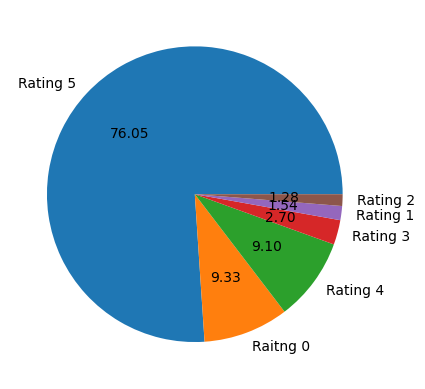

In [16]:
plt.pie(data['Rating'].value_counts(),labels=['Rating 5','Raitng 0','Rating 4','Rating 3','Rating 1','Rating 2'], autopct='%0.2f')
plt.show()

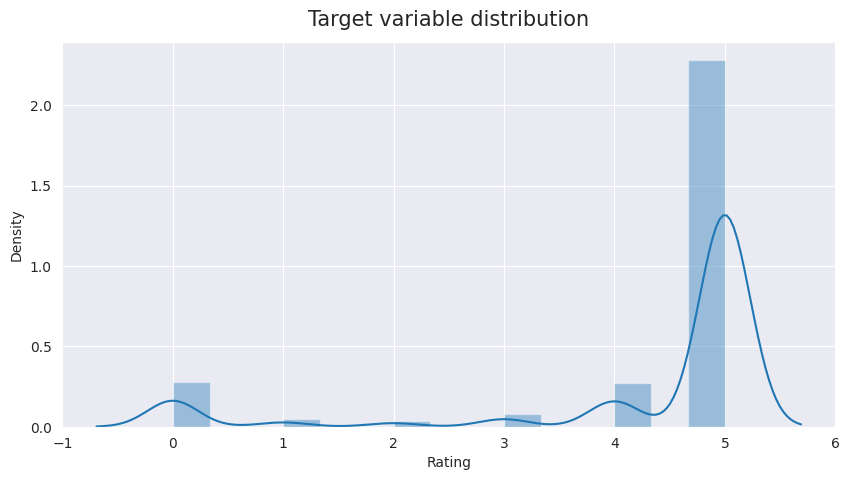

None

np.float64(-2.1282029504008753)

In [17]:
sns.set_style('darkgrid')
plt.figure(figsize = (10, 5))
sns.distplot(data.Rating, kde = True, bins = 15)
plt.title('Target variable distribution', y = 1.02, fontsize = 15)
display(plt.show(), data.Rating.skew())

1. A negative skewness value indicates that the distribution is skewed towards left

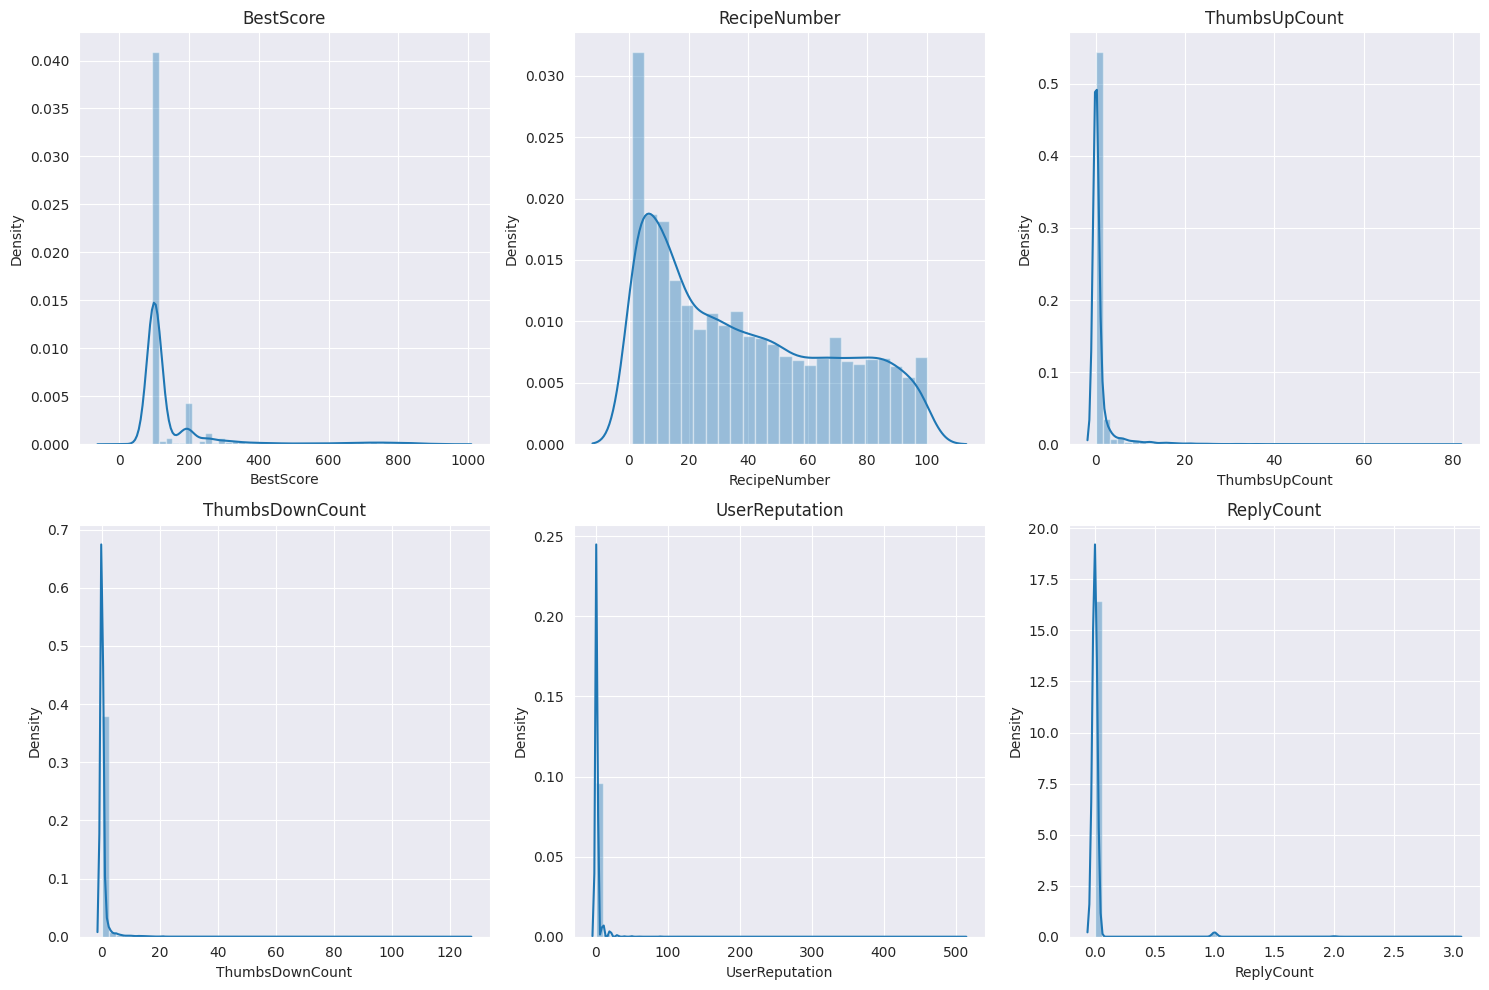

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution plot
columns = ['BestScore', 'RecipeNumber', 'ThumbsUpCount', 'ThumbsDownCount', 'UserReputation', 'ReplyCount']

num_plots = len(columns)
num_cols = min(num_plots, 3)  # Display up to 3 plots per row
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) # Creating subplots for each column

for i, column in enumerate(columns):
    sns.distplot(data[column], ax=axes[i//num_cols, i%num_cols])  # Accessing subplot using row and column indices
    axes[i//num_cols, i%num_cols].set_title(column)

plt.tight_layout()
plt.show()


* from the above graph we can say that data is right skewed

# Checking Outliers

<Axes: ylabel='Rating'>

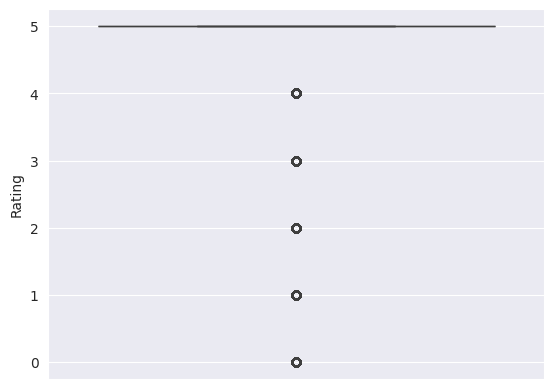

In [19]:
sns.boxplot(data['Rating'])

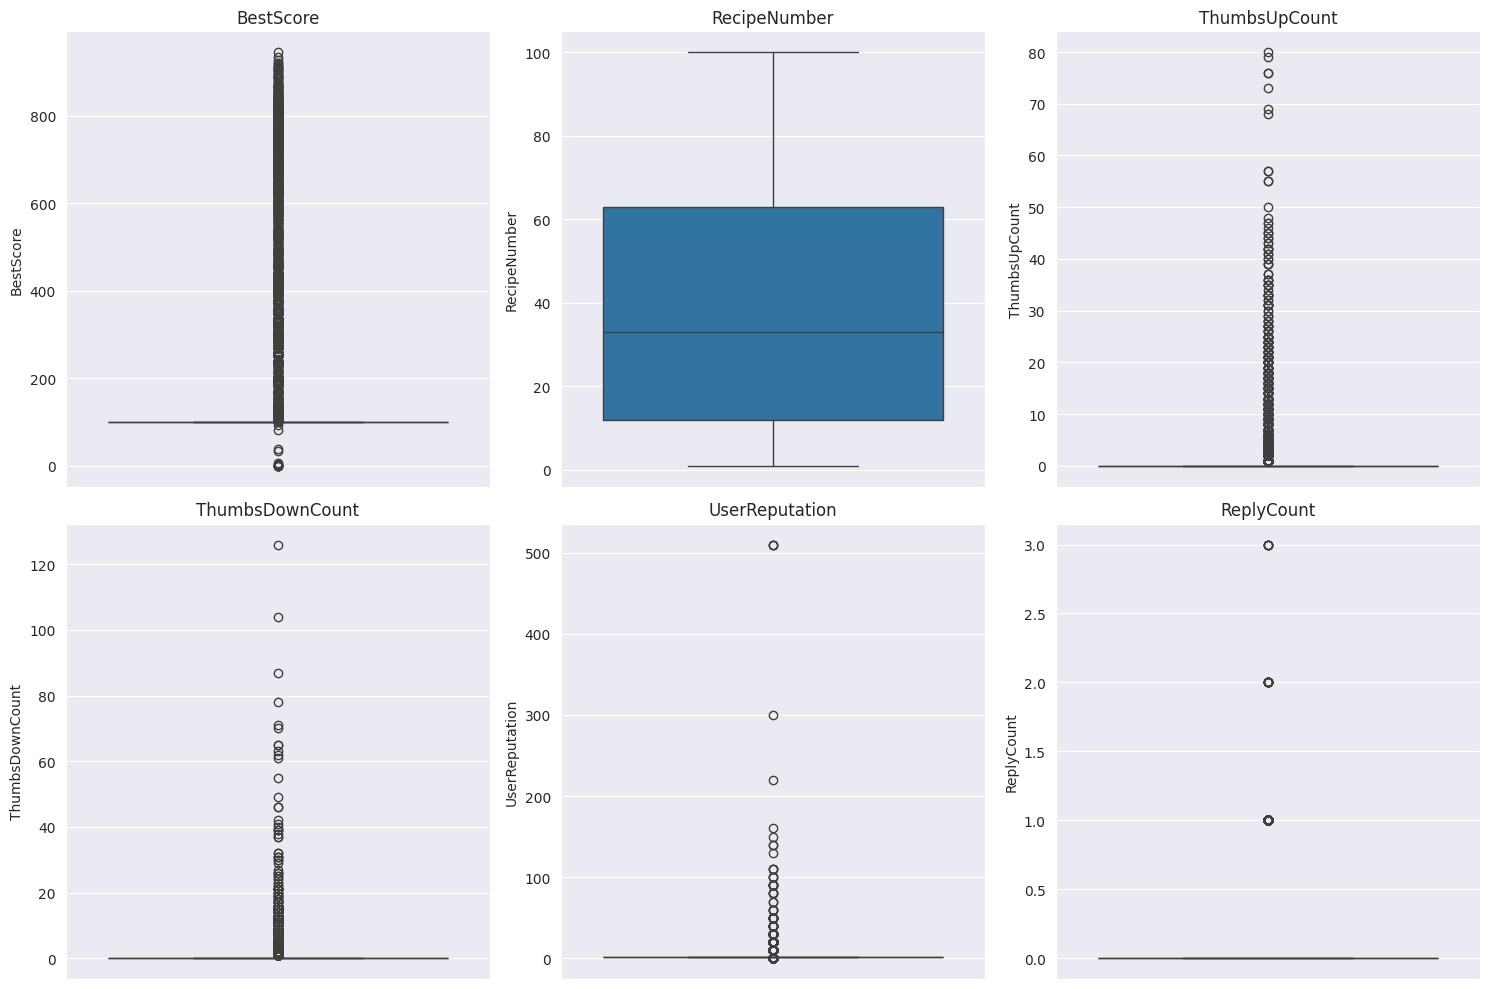

In [20]:
columns = ['BestScore', 'RecipeNumber', 'ThumbsUpCount', 'ThumbsDownCount', 'UserReputation', 'ReplyCount']

num_plots = len(columns)
num_cols = min(num_plots, 3)  # Display up to 3 plots per row
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows)) # Creating subplots for each column

for i, column in enumerate(columns):
    sns.boxplot(data[column], ax=axes[i//num_cols, i%num_cols])  # Accessing subplot using row and column indices
    axes[i//num_cols, i%num_cols].set_title(column)

plt.tight_layout()
plt.show()


# Correlation

<Axes: >

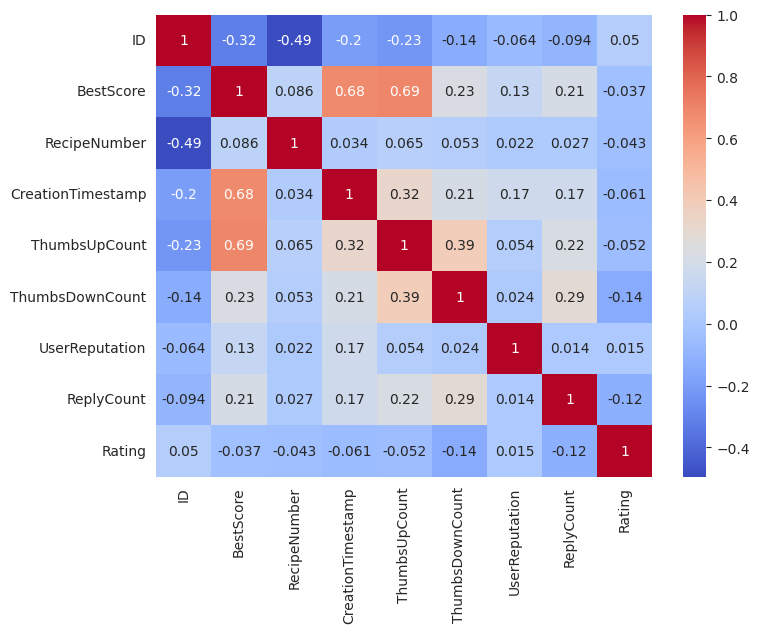

In [21]:
numeric_features =['ID',
                   'BestScore',
                   'RecipeNumber',
                   'CreationTimestamp',
                   'ThumbsUpCount',
                   'ThumbsDownCount',
                   'UserReputation',
                   'ReplyCount',
                   'Rating']
corre= data[numeric_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corre, annot = True, cmap = 'coolwarm')   # correlation Heat Map

* Their is high correlation between CreationTimestamp, BestScore, ThumbsUpCount


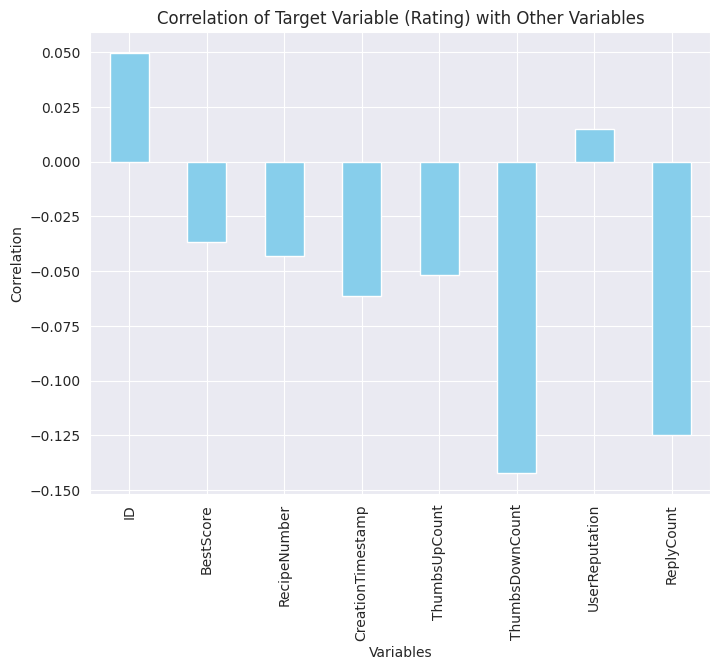

In [22]:
target_correlation = corre['Rating']
plt.figure(figsize=(8, 6))
target_correlation.drop('Rating').plot(kind='bar', color='skyblue')
plt.title('Correlation of Target Variable (Rating) with Other Variables')
plt.xlabel('Variables')
plt.ylabel('Correlation')
plt.show()


In [23]:
top_rated = (                               # Finding recipes which has highest ratings
    data.groupby('RecipeName')['Rating']
    .mean()
    .sort_values(ascending=False)
)

top_rated.head(10)

,Rating
RecipeName,
Rustic Italian Tortellini Soup,4.739336
Corn Pudding,4.692308
Zucchini Pizza Casserole,4.657371
Comforting Chicken Noodle Soup,4.654321
Special Banana Nut Bread,4.648936
Pumpkin Bread,4.639706
Vegetarian Linguine,4.631579
Cheeseburger Soup,4.623188
Macaroni Coleslaw,4.608392


In [24]:
least_liked = (                            # Finding recipes which has lowest ratings
    data.groupby('RecipeName')['Rating']
    .mean()
    .sort_values(ascending=True)
)

least_liked.head(10)

,Rating
RecipeName,
Pineapple Orange Cake,2.682759
Fluffy Key Lime Pie,2.740000
Caramel Heavenlies,3.125000
Peanut Butter Cup Cheesecake,3.768116
Flavorful Pot Roast,3.774194
Li’l Cheddar Meat Loaves,3.783069
Caramel-Pecan Cheesecake Pie,3.786260
Twice-Baked Potato Casserole,3.825581
Lime Chicken Tacos,3.861538


In [25]:
columns=['ID','CommentID','UserName','UserID','BestScore'] # dropping columns
data=data.drop(columns=columns)

CommentID,UserName,UserId might not be usefull for predicting Rating
as each user will be associated will only one or few recipes.

CreationTimestamp,BestScore have positive correlation with ThumbsUpCount

In [26]:
data.head()

,RecipeNumber,RecipeCode,RecipeName,UserReputation,CreationTimestamp,ReplyCount,ThumbsUpCount,ThumbsDownCount,Rating,Recipe_Review
0,71,12259,Banana Bars with Cream Cheese Frosting,20,2021-06-03 10:44:38,0,0,0,5,great recipe! I have made them just as written...
1,88,8202,Simple Taco Soup,1,2021-06-03 10:57:32,0,0,1,5,This is an easy and quick recipe that is great...
2,3,2832,Cheeseburger Soup,1,2021-06-03 10:49:17,0,0,0,3,I think I was looking for something extra spec...
3,50,100276,Grilled Huli Huli Chicken,1,2021-06-02 15:48:19,0,0,0,5,This is our favorite grilled chicken recipe. ...
4,12,19731,Cauliflower Soup,1,2021-06-03 11:04:20,0,0,0,4,Great basic recipe. I added 2 teaspoons Tuscan...


# Text Preprocessing

In [27]:
def clean_text(text):
    if not isinstance(text, str):  # Checking if non-string (e.g., NaN)
        return ''

    text = text.lower()  # Converting to lowercase

    text = re.sub(r'http\S+', '', text)  # Removing links
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Removing punctuation

    return text

data['Recipe_Review'] = data['Recipe_Review'].apply(clean_text)


In [28]:
data['Recipe_Review']

,Recipe_Review
0,great recipe i have made them just as written ...
1,this is an easy and quick recipe that is great...
2,i think i was looking for something extra spec...
3,this is our favorite grilled chicken recipe g...
4,great basic recipe i added teaspoons tuscan s...
...,...
13631,delicious very easy to make one minor change ...
13632,i made this pie for my family and they loved i...
13633,very tasty
13634,i have made this numerous times its so good a...


In [29]:
#!pip install textblob
from textblob import TextBlob

In [30]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

In [31]:
data['sentiment_polarity'] = data['Recipe_Review'].apply(get_polarity)

data['sentiment_subjectivity'] = data['Recipe_Review'].apply(get_subjectivity)

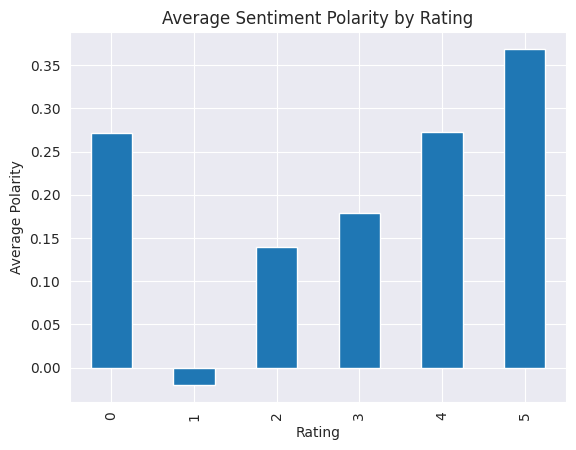

In [32]:
avg_sentiment = data.groupby('Rating')[
    'sentiment_polarity'
].mean()

avg_sentiment.plot(kind='bar')

plt.title('Average Sentiment Polarity by Rating')

plt.ylabel('Average Polarity')

plt.show()

In [33]:
data['review_length'] = data['Recipe_Review'].apply(
    lambda x: len(str(x))
)

In [34]:
data['word_count'] = data['Recipe_Review'].apply(
    lambda x: len(str(x).split())
)

<Axes: >

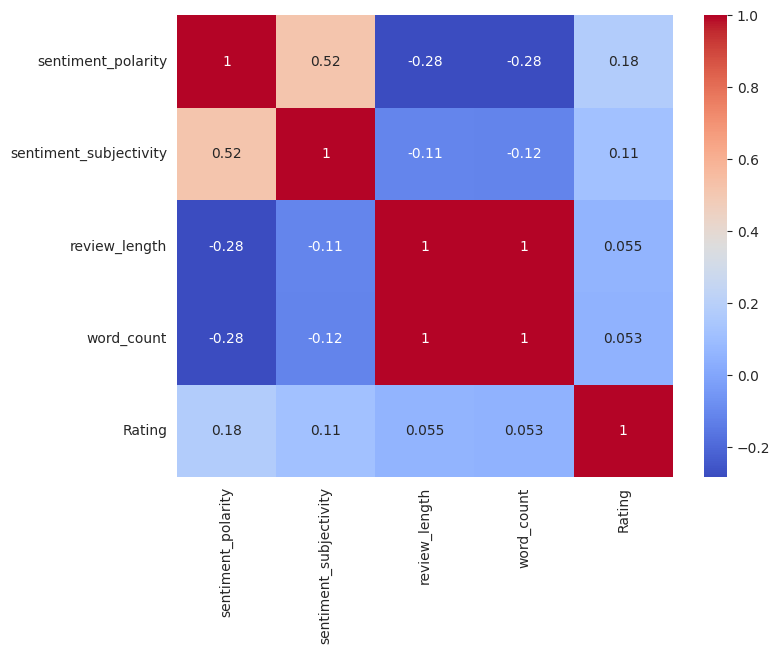

In [35]:
features_corr = [
    'sentiment_polarity',
    'sentiment_subjectivity',
    'review_length',
    'word_count',
    'Rating'
]
corre= data[features_corr].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corre, annot = True, cmap = 'coolwarm')

# Encoding RecipeName

In [36]:
encoder = LabelEncoder()
data["RecipeName"]=encoder.fit_transform(data["RecipeName"])
RecipeName_no={ index: label for index, label in enumerate(encoder.classes_)}
RecipeName_no

{0: 'Amish Breakfast Casserole',
 1: 'Apple Pie',
 2: 'Asian Chicken Thighs',
 3: 'Bacon Macaroni Salad',
 4: 'Baked Mushroom Chicken',
 5: 'Baked Spaghetti',
 6: 'Baked Tilapia',
 7: 'Banana Bars with Cream Cheese Frosting',
 8: 'Basic Banana Muffins',
 9: 'Basic Homemade Bread',
 10: 'Best Ever Banana Bread',
 11: 'Best Ever Potato Soup',
 12: 'Big Soft Ginger Cookies',
 13: 'Black Bean ‘n’ Pumpkin Chili',
 14: 'Blueberry French Toast',
 15: 'Brown Sugar Oatmeal Pancakes',
 16: 'Bruschetta Chicken',
 17: 'Buttery Cornbread',
 18: 'Caramel Heavenlies',
 19: 'Caramel-Pecan Cheesecake Pie',
 20: 'Cauliflower Soup',
 21: 'Cheeseburger Paradise Soup',
 22: 'Cheeseburger Soup',
 23: 'Cheesy Ham Chowder',
 24: 'Cherry Bars',
 25: 'Chicken Penne Casserole',
 26: 'Chicken Wild Rice Soup',
 27: 'Chicken and Dumplings',
 28: 'Chocolate Caramel Candy',
 29: 'Chocolate Chip Oatmeal Cookies',
 30: 'Chocolate Guinness Cake',
 31: 'Chocolate-Strawberry Celebration Cake',
 32: 'Chunky Apple Cake',
 3

# OOT Validation

In [37]:
# data = data.sort_values('CreationTimestamp')

In [38]:
# train_data, test_data = train_test_split(
#     data,
#     test_size=0.2,
#     shuffle=False
# )

In [39]:
# print("Train Range:")
# print(
#     train_data['CreationTimestamp'].min(),
#     "to",
#     train_data['CreationTimestamp'].max()
# )

# print()

# print("Test Range:")
# print(
#     test_data['CreationTimestamp'].min(),
#     "to",
#     test_data['CreationTimestamp'].max()
# )

In [40]:
# X_train = train_data.drop(columns=['Rating'])

# y_train = train_data['Rating']

# X_test = test_data.drop(columns=['Rating'])

# y_test = test_data['Rating']

In [41]:
# X_train = X_train.drop(columns=['CreationTimestamp'])

# X_test = X_test.drop(columns=['CreationTimestamp'])

In [42]:
# X_train

# Splitting Dataset into train and test data

In [43]:
X=data.drop('Rating', axis=1)
y=data['Rating']
X.shape, y.shape

((13634, 13), (13634,))

In [44]:
X = X.drop(columns=['CreationTimestamp'])


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=True,
    stratify=y,
    random_state=42
    )
X_train.shape, X_test.shape

((10907, 12), (2727, 12))

In [46]:
X_train_num=X_train.drop('Recipe_Review',axis=1)
X_test_num=X_test.drop('Recipe_Review',axis=1)

In [47]:
X_train_txt=X_train['Recipe_Review']
X_test_txt=X_test['Recipe_Review']
X_train_txt

,Recipe_Review
10795,absolutely the best chili weve ever had i use...
7527,ive been making this for years my recipe has...
5299,the first day i received the premiere issue wi...
6579,great recipe i modified slightly based on oth...
477,made this for bookclub and it was delicious t...
...,...
5903,this is a really good recipe i made it exactl...
9452,how do you print out this recipe dont see an o...
8706,been making these for awhile now never disappo...
6807,even my non coleslaw liking kids loved this re...


# Converting text data into numerical data

In [48]:
#Using TF- IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X_train_txt_vec=vectorizer.fit_transform(X_train_txt)
X_test_txt_vec=vectorizer.transform(X_test_txt)
X_train_txt_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 171353 stored elements and shape (10907, 10943)>

In [49]:
X_train_txt_vec[1].toarray()

array([[0., 0., 0., ..., 0., 0., 0.]])

In [50]:
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['aa', 'aback', 'abd', ..., 'zucs', 'zucsp', 'zuke'], dtype=object)

# Finding important words from user reviews which has impact on ratings

In [51]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_txt_vec, y_train)

LogisticRegression(max_iter=1000)

In [52]:
coefficients = lr_model.coef_

In [53]:
positive_class_idx = list(lr_model.classes_).index(5)

positive_coeffs = coefficients[
    positive_class_idx
]

In [54]:
top_positive_idx = positive_coeffs.argsort()[-50:]

top_positive_words = [
    feature_names[i]
    for i in top_positive_idx
]

top_positive_scores = [
    positive_coeffs[i]
    for i in top_positive_idx
]

In [55]:
for word, score in zip(
    top_positive_words,
    top_positive_scores
):
    print(word, ":", score)

olive : 1.1314692989876305
doubled : 1.139397983208508
slightly : 1.1440938766832587
yum : 1.1593730735973777
home : 1.1714248579878799
rave : 1.176574647136836
sharing : 1.1869079363206774
picky : 1.1912012452781147
change : 1.1949488304002926
delish : 1.197172470863322
glad : 1.2060487211598605
written : 1.2174967941178463
party : 1.2183262665186574
soooo : 1.25059158026646
tsp : 1.252370062976459
outstanding : 1.2600399612704694
recipe : 1.2629474280926563
times : 1.263627707076279
year : 1.2821810393796758
friends : 1.2880819177293805
hand : 1.2928379422486496
easy : 1.3109316435156595
makes : 1.3221549817910734
day : 1.326681517185245
loves : 1.3476572689913673
summer : 1.3573006378996635
wow : 1.4037502164132287
definitely : 1.4103441590739556
husband : 1.4256655513599852
chopped : 1.428923018752917
hit : 1.5615681875677105
keeper : 1.7060045721021597
fabulous : 1.7420619283898875
awesome : 1.7694370519568556
years : 1.905519149176241
family : 1.907516754296074
favorite : 1.96814

In [56]:
top_negative_idx = positive_coeffs.argsort()[:50]

top_negative_words = [
    feature_names[i]
    for i in top_negative_idx
]

top_negative_scores = [
    positive_coeffs[i]
    for i in top_negative_idx
]

for i in top_negative_idx:
    print(
        feature_names[i],
        ":",
        positive_coeffs[i]
    )

bland : -3.4415105347627466
okay : -2.846973228581483
care : -2.4169112647496624
disappointed : -2.1676108522280866
ok : -2.040892718309999
pretty : -1.8438046666890746
soupy : -1.7472741964218546
needs : -1.7377117166684701
tortillas : -1.6692959035966872
dry : -1.6662133944158348
bad : -1.636374837442055
wasnt : -1.636141583317644
thought : -1.6338170195040442
maybe : -1.623340068539278
think : -1.5675763695030076
isnt : -1.4686727506485064
sorry : -1.4639469411070813
tasted : -1.4544819089484564
sweet : -1.444750116634584
opinion : -1.431901232658227
like : -1.4046037498512347
soggy : -1.3995926358566186
dumplings : -1.3835340720329878
wrong : -1.3750019628160106
sounds : -1.3433428182978056
taste : -1.335856003077762
missing : -1.312565218948032
waste : -1.2793974993902646
watery : -1.2688021946665962
overall : -1.252822554235169
terrible : -1.233100855346584
lot : -1.2217061977130865
liquid : -1.2009234377957703
flavor : -1.1963671921064134
way : -1.1859890623897458
worst : -1.162

In [57]:
positive_words = set(top_positive_words)

negative_words = set(top_negative_words)

In [58]:
def count_positive_words(text):

    words = str(text).lower().split()

    return sum(
        word in positive_words
        for word in words
    )

In [59]:
def count_negative_words(text):

    words = str(text).lower().split()

    return sum(
        word in negative_words
        for word in words
    )

In [60]:
X_train_num['positive_word_count'] = data[
    'Recipe_Review'
].apply(count_positive_words)

X_train_num['negative_word_count'] = data[
    'Recipe_Review'
].apply(count_negative_words)

X_test_num['positive_word_count'] = data[
    'Recipe_Review'
].apply(count_positive_words)

X_test_num['negative_word_count'] = data[
    'Recipe_Review'
].apply(count_negative_words)

In [61]:
X_train_num['net_sentiment_score'] = (
    X_train_num['positive_word_count']
    -
    X_train_num['negative_word_count']
)

X_test_num['net_sentiment_score'] = (
    X_test_num['positive_word_count']
    -
    X_test_num['negative_word_count']
)

# Scaling Numerical Features

In [62]:
ss=StandardScaler()
X_train_num_ss = pd.DataFrame( ss.fit_transform(X_train_num),columns=X_train_num.columns )
X_test_num_ss = pd.DataFrame( ss.transform(X_test_num),columns=X_test_num.columns )
X_train_num_ss.head()

,RecipeNumber,RecipeCode,RecipeName,UserReputation,ReplyCount,ThumbsUpCount,ThumbsDownCount,sentiment_polarity,sentiment_subjectivity,review_length,word_count,positive_word_count,negative_word_count,net_sentiment_score
0,-1.273755,-0.312381,-0.295000,-0.107544,-0.102178,-0.263106,-0.163294,-0.504630,0.331134,-0.226164,-0.231593,1.015593,-0.62334,1.260970
1,-0.198465,0.448442,-0.364084,-0.107544,-0.102178,-0.263106,-0.163294,0.595774,0.428418,0.077597,0.021912,1.483552,-0.62334,1.694367
2,-0.668904,-0.838314,0.568545,-0.107544,-0.102178,-0.263106,-0.163294,0.137273,0.428418,-0.153261,-0.199905,0.547633,-0.62334,0.827574
3,0.003152,0.261657,1.155756,-0.107544,-0.102178,-0.263106,-0.163294,-0.827279,-0.778018,0.059371,0.021912,0.547633,-0.62334,0.827574
4,1.179250,0.214888,0.741254,-0.107544,-0.102178,-0.263106,-0.163294,0.595774,-0.328232,-0.596753,-0.516786,0.079674,-0.62334,0.394177


# Combining both text data and numerical data

In [63]:
X_train_combined = np.hstack([X_train_num_ss,X_train_txt_vec.toarray()] )
X_test_combined = np.hstack([X_test_num_ss,X_test_txt_vec.toarray()] )
X_train_combined.shape

(10907, 10957)

# Model Building

# Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_combined,y_train)

LogisticRegression(max_iter=1000)

In [65]:
print('Training Score:',lr.score(X_train_combined,y_train))

Training Score: 0.8187402585495553


In [66]:
y_pred = lr.predict(X_test_combined)
print('Testing Score:',lr.score(X_test_combined,y_test))

Testing Score: 0.7719105243857719


In [67]:
y_score_lr=lr.predict_proba(X_test_combined)
y_score_lr

array([[7.48152901e-02, 9.28968932e-04, 2.98770376e-03, 7.96617022e-03,
        4.13709581e-02, 8.71930909e-01],
       [1.34085035e-02, 1.46466453e-04, 1.28556382e-04, 9.20587821e-04,
        1.56958263e-02, 9.69700060e-01],
       [5.61267163e-02, 1.07374446e-03, 5.82852866e-04, 4.06934972e-03,
        5.69082303e-02, 8.81239106e-01],
       ...,
       [2.43098569e-01, 7.54587695e-03, 5.53444662e-03, 1.48301148e-02,
        4.52095533e-02, 6.83781439e-01],
       [2.42924294e-01, 1.53575614e-02, 1.49577472e-02, 4.11733993e-02,
        1.09464948e-01, 5.76122049e-01],
       [2.73860314e-01, 4.36211918e-02, 1.78268280e-02, 4.61227361e-02,
        9.17639565e-02, 5.26804974e-01]])

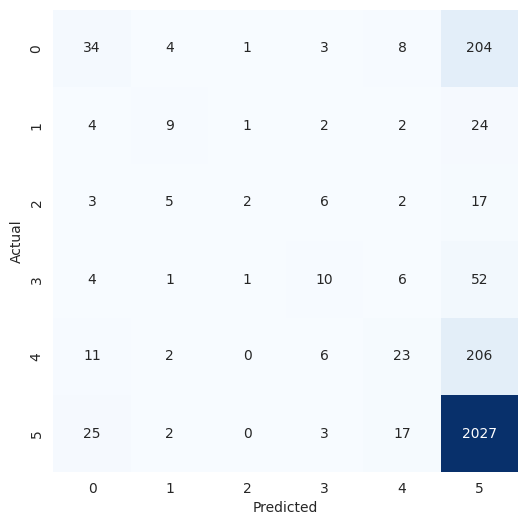

Classification Report:
-------------------
               precision    recall  f1-score   support

           0       0.42      0.13      0.20       254
           1       0.39      0.21      0.28        42
           2       0.40      0.06      0.10        35
           3       0.33      0.14      0.19        74
           4       0.40      0.09      0.15       248
           5       0.80      0.98      0.88      2074

    accuracy                           0.77      2727
   macro avg       0.46      0.27      0.30      2727
weighted avg       0.70      0.77      0.71      2727



In [68]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:\n-------------------\n', clr)

# LogisticRegression(with Hyperparameter)

In [69]:
# lr=LogisticRegression(max_iter=20000)
# param_grid= {'C': [0.01, 0.1, 1, 10, 100],
#             'penalty': ['l1','l2'],
#             'solver': ['lbfgs','liblinear','newton-cg'],
#             'multi_class':['auto','ovr']
#           }

# grid= GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
# grid.fit(X_train_combined, y_train)
# best_params = grid.best_params_
# best_params

In [70]:
lrhp=LogisticRegression(C=10,
                        penalty='l2',
                        solver='newton-cg',
                        multi_class='ovr')
lrhp.fit(X_train_combined,y_train)

LogisticRegression(C=10, multi_class='ovr', solver='newton-cg')

In [71]:
print('Training Score:',lrhp.score(X_train_combined,y_train))

Training Score: 0.909691024112955


In [72]:
y_pred = lrhp.predict(X_test_combined)
print('Testing Score:',lrhp.score(X_test_combined,y_test))

Testing Score: 0.7642097543087643


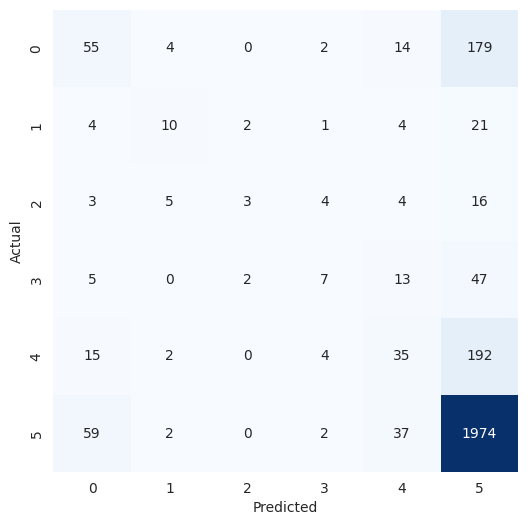

Classification Report:LogisticRegression
-------------------
               precision    recall  f1-score   support

           0       0.39      0.22      0.28       254
           1       0.43      0.24      0.31        42
           2       0.43      0.09      0.14        35
           3       0.35      0.09      0.15        74
           4       0.33      0.14      0.20       248
           5       0.81      0.95      0.88      2074

    accuracy                           0.76      2727
   macro avg       0.46      0.29      0.33      2727
weighted avg       0.71      0.76      0.72      2727



In [73]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:LogisticRegression\n-------------------\n', clr)

# RandomForest Classsifier

In [74]:
rfc=RandomForestClassifier()
rfc.fit(X_train_combined,y_train)

RandomForestClassifier()

In [75]:
print('Traning Score:', rfc.score(X_train_combined,y_train))

Traning Score: 0.9994498945631246


In [76]:
y_pred = rfc.predict(X_test_combined)
print('Testing Score:',rfc.score(X_test_combined,y_test))

Testing Score: 0.7722772277227723


In [77]:
y_score_rfc=rfc.predict_proba(X_test_combined)
y_score_rfc

array([[0.05, 0.  , 0.  , 0.  , 0.  , 0.95],
       [0.04, 0.  , 0.  , 0.01, 0.02, 0.93],
       [0.09, 0.  , 0.  , 0.05, 0.08, 0.78],
       ...,
       [0.69, 0.02, 0.  , 0.  , 0.01, 0.28],
       [0.1 , 0.  , 0.  , 0.03, 0.07, 0.8 ],
       [0.13, 0.01, 0.  , 0.01, 0.02, 0.83]])

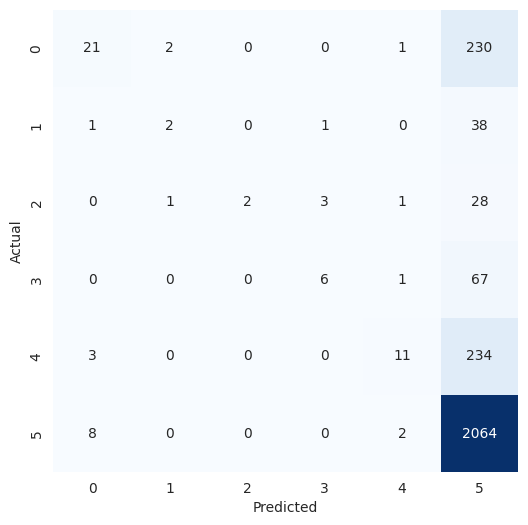

Classification Report:
-------------------
               precision    recall  f1-score   support

           0       0.64      0.08      0.15       254
           1       0.40      0.05      0.09        42
           2       1.00      0.06      0.11        35
           3       0.60      0.08      0.14        74
           4       0.69      0.04      0.08       248
           5       0.78      1.00      0.87      2074

    accuracy                           0.77      2727
   macro avg       0.68      0.22      0.24      2727
weighted avg       0.75      0.77      0.69      2727



In [78]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:\n-------------------\n', clr)

# RandomForestClassifier (With HyperParameter)

In [79]:
# param_grid = {
#    'n_estimators': [100,200],
#    'max_depth': [10, 15],
#    'criterion':['gini','entropy'],
#    'min_samples_split': [5, 10],
#    'min_samples_leaf': [2, 4]
# }
# grid_search = GridSearchCV(rfc, param_grid, cv=5, scoring='accuracy',verbose=2, n_jobs=-1)
# grid_search.fit(X_train_combined, y_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

In [80]:
rfchp=RandomForestClassifier(n_estimators = 100,
                             min_samples_split = 5,
                             min_samples_leaf = 2,
                             max_depth = 15,
                             criterion = 'entropy')
rfchp.fit(X_train_combined,y_train)

RandomForestClassifier(criterion='entropy', max_depth=15, min_samples_leaf=2,
                       min_samples_split=5)

In [81]:
print('Traning Score:', rfchp.score(X_train_combined,y_train))

Traning Score: 0.760520766480242


In [82]:
y_pred = rfchp.predict(X_test_combined)
print('Testing Score:',rfchp.score(X_test_combined,y_test))

Testing Score: 0.7605427209387605


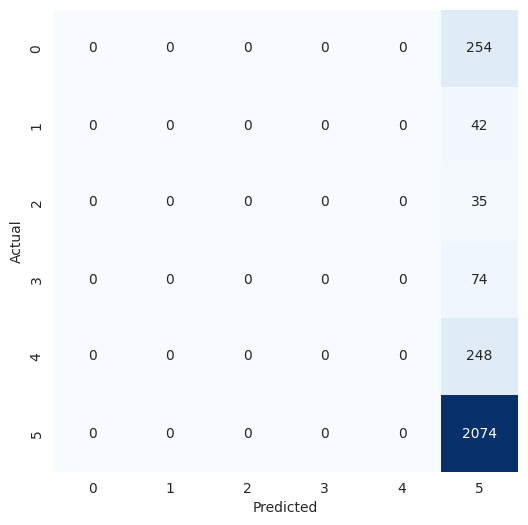

Classification Report:RandomForestClassifier
-------------------
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       254
           1       0.00      0.00      0.00        42
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        74
           4       0.00      0.00      0.00       248
           5       0.76      1.00      0.86      2074

    accuracy                           0.76      2727
   macro avg       0.13      0.17      0.14      2727
weighted avg       0.58      0.76      0.66      2727



In [83]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:RandomForestClassifier\n-------------------\n', clr)

# HistGradientBoostingClassifier

In [84]:
clf=HistGradientBoostingClassifier()
clf.fit(X_train_combined,y_train)

HistGradientBoostingClassifier()

In [85]:
print('Training Score:',clf.score(X_train_combined,y_train))

Training Score: 0.8783350142110571


In [86]:
y_pred = clf.predict(X_test_combined)
print('Testing Score:',clf.score(X_test_combined,y_test))

Testing Score: 0.7759442610927759


In [87]:
y_score_clf=clf.predict_proba(X_test_combined)
y_score_clf

array([[4.08234046e-02, 3.34136133e-04, 3.62002383e-04, 3.39002048e-03,
        3.36465669e-02, 9.21443870e-01],
       [4.38175473e-02, 6.85082130e-04, 4.63204557e-04, 7.43994989e-03,
        4.17574126e-02, 9.05836804e-01],
       [3.93112020e-02, 4.21529391e-04, 1.88640784e-04, 1.80375325e-03,
        2.85375019e-02, 9.29737373e-01],
       ...,
       [1.47020069e-01, 1.85044752e-03, 8.08328669e-04, 7.66044990e-03,
        3.15440084e-02, 8.11116697e-01],
       [1.23690282e-01, 6.69699873e-04, 1.00779921e-03, 8.51450532e-03,
        5.31613552e-02, 8.12956359e-01],
       [2.25044013e-01, 9.81610619e-03, 1.06850376e-03, 1.63238035e-02,
        9.13577151e-02, 6.56389859e-01]])

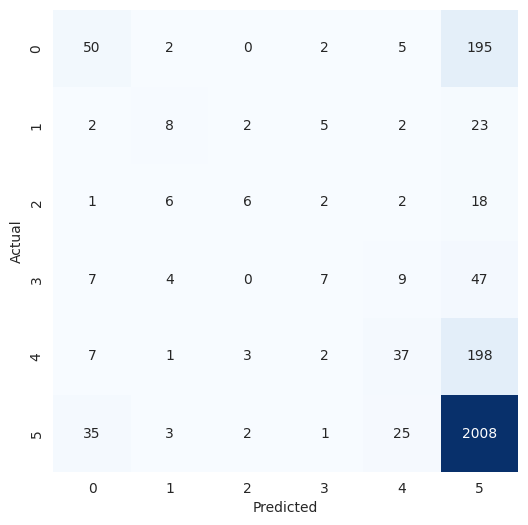

Classification Report: GradientBoostingClassifier
-------------------
               precision    recall  f1-score   support

           0       0.49      0.20      0.28       254
           1       0.33      0.19      0.24        42
           2       0.46      0.17      0.25        35
           3       0.37      0.09      0.15        74
           4       0.46      0.15      0.23       248
           5       0.81      0.97      0.88      2074

    accuracy                           0.78      2727
   macro avg       0.49      0.30      0.34      2727
weighted avg       0.72      0.78      0.73      2727



In [88]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report: GradientBoostingClassifier\n-------------------\n', clr)

# XG Boost

In [89]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train_combined,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [90]:
print("Traning score:",xgb.score(X_train_combined,y_train))

Traning score: 0.9077656550838911


In [91]:
y_pred = xgb.predict(X_test_combined)
print("Testing score:",xgb.score(X_test_combined,y_test))

Testing score: 0.7766776677667767


In [92]:
y_score_xgb=xgb.predict_proba(X_test_combined)
y_score_xgb

array([[6.4093545e-02, 2.9017890e-04, 5.2397192e-04, 4.3407427e-03,
        3.5480954e-02, 8.9527065e-01],
       [8.0891900e-02, 1.4441431e-03, 5.0654920e-04, 1.2991172e-02,
        6.8882242e-02, 8.3528405e-01],
       [8.0417097e-02, 4.5482910e-04, 2.3608953e-04, 4.8777759e-03,
        3.5666931e-02, 8.7834728e-01],
       ...,
       [3.6457112e-01, 1.9799140e-03, 5.8260240e-04, 5.2569355e-03,
        2.9854234e-02, 5.9775519e-01],
       [2.5977942e-01, 1.7103202e-03, 9.0753025e-04, 1.4190916e-02,
        6.0748030e-02, 6.6266376e-01],
       [1.9937606e-01, 7.6359203e-03, 2.9792138e-03, 2.9602217e-02,
        1.0190480e-01, 6.5850174e-01]], dtype=float32)

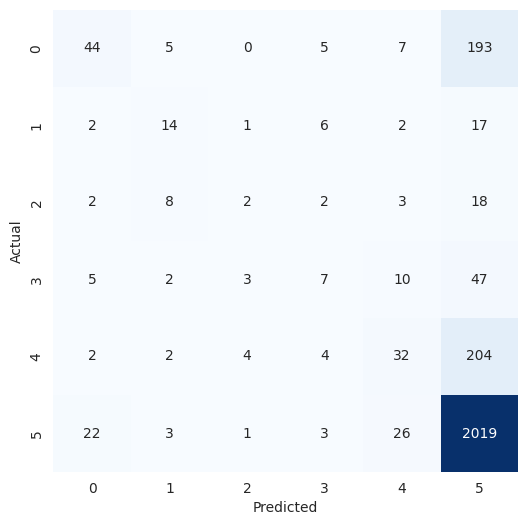

Classification Report:XGBoostClassifier
-------------------
               precision    recall  f1-score   support

           0       0.57      0.17      0.27       254
           1       0.41      0.33      0.37        42
           2       0.18      0.06      0.09        35
           3       0.26      0.09      0.14        74
           4       0.40      0.13      0.20       248
           5       0.81      0.97      0.88      2074

    accuracy                           0.78      2727
   macro avg       0.44      0.29      0.32      2727
weighted avg       0.72      0.78      0.72      2727



In [93]:
cm = confusion_matrix(y_test, y_pred)
clr= classification_report(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cbar=False, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Classification Report:XGBoostClassifier\n-------------------\n', clr)

# Acurracy of Models

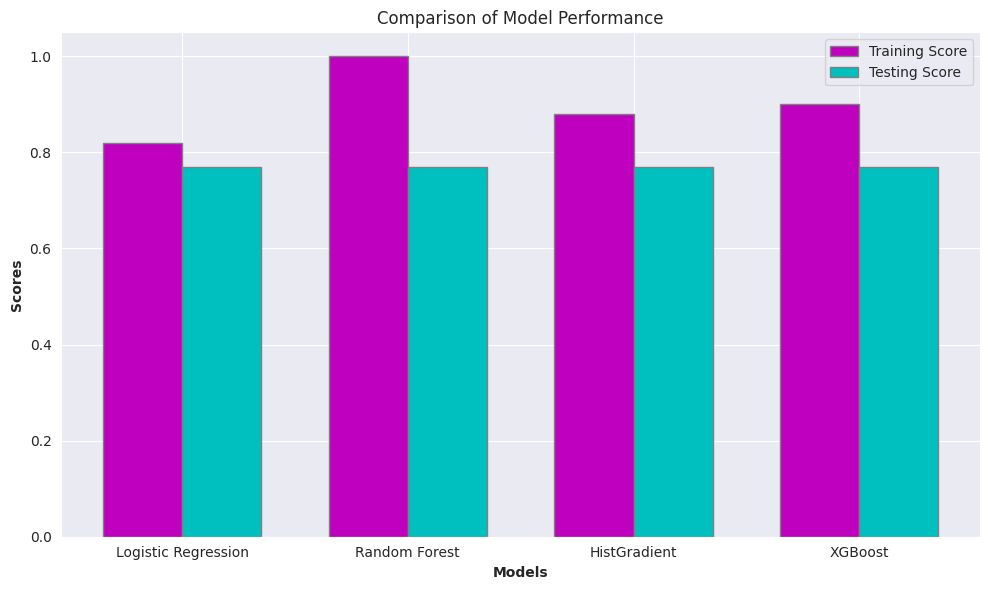

In [100]:
import matplotlib.pyplot as plt  # accuracy with oot(out of time validation)

models = ['Logistic Regression', 'Random Forest', 'HistGradient','XGBoost']
training_scores = [0.82, 1, 0.88, 0.90]
testing_scores = [0.77, 0.77, 0.77, 0.77]

bar_width = 0.35

r1 = range(len(models))
r2 = [x + bar_width for x in r1]

plt.figure(figsize=(10, 6))
plt.bar(r1, training_scores, color='m', width=bar_width, edgecolor='grey', label='Training Score')
plt.bar(r2, testing_scores, color='c', width=bar_width, edgecolor='grey', label='Testing Score')

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(models))], models)
plt.title('Comparison of Model Performance')
plt.legend()

plt.tight_layout()
plt.show()


# ROC

In [101]:
from sklearn.preprocessing import LabelBinarizer

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape  # (n_samples, n_classes)

(2727, 6)

In [102]:
label_binarizer.transform([3])

array([[0, 0, 0, 1, 0, 0]])

In [103]:
classes = label_binarizer.classes_
classes

array([0, 1, 2, 3, 4, 5])

In [104]:
model_names=['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost']

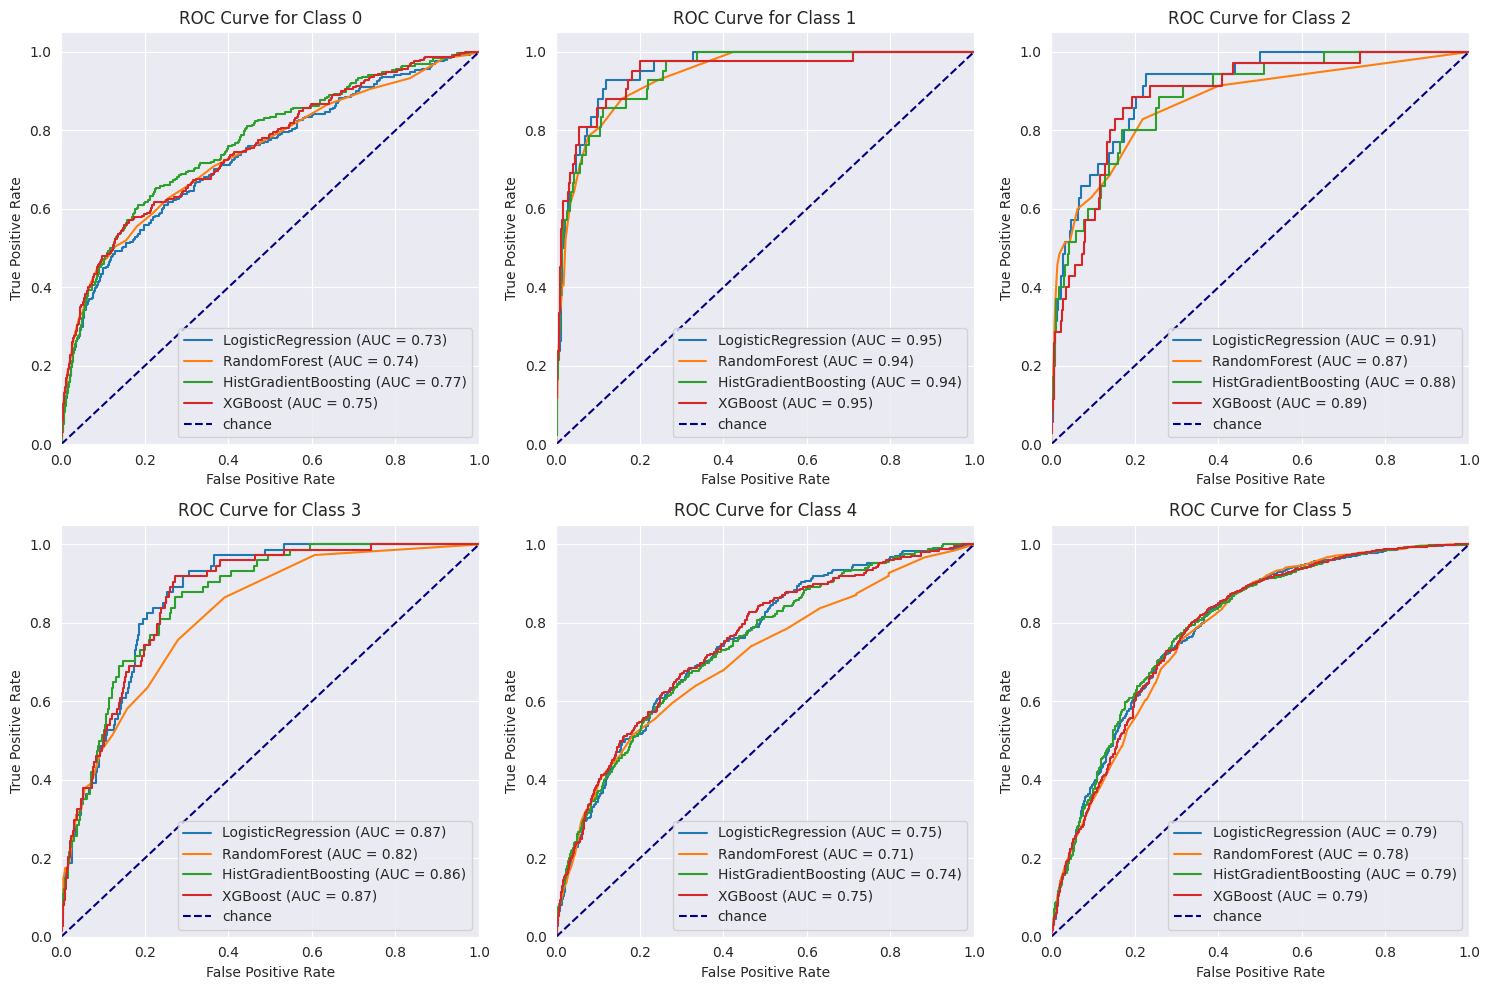

In [105]:
def plot_roc_curves_for_classes(y_train, y_scores_list, classes, model_names):
    # Compute the number of rows and columns for subplots
    num_plots = len(classes)
    num_cols = min(num_plots, 3)  # Display 3 plots per row
    num_rows = (num_plots + num_cols - 1) // num_cols

    # Create subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
    axs = axs.flatten()  # Flatten the 2D array of subplots to simplify indexing

    # Iterate over each class
    for i, class_label in enumerate(classes):
        # Select the appropriate subplot
        ax = axs[i]

        # Iterate over each model and plot its ROC curve for the current class
        for model_name, y_scores in zip(model_names, y_scores_list):
            fpr, tpr, _ = roc_curve(y_onehot_test[:, i], y_scores[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')


        ax.plot([0, 1], [0, 1], color='navy', linestyle='--', label='chance')


        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'ROC Curve for Class {class_label}')
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_roc_curves_for_classes(y_train, [y_score_lr, y_score_rfc, y_score_clf, y_score_xgb], classes, ['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost'])
